![image](https://analyticsindiamag.com/7-types-classification-algorithms/screen-shot-2018-01-19-at-11-01-28-am/)

In [1]:
import numpy as np
import keras as K
import tensorflow as tf
import pandas as pd
import keras

import math
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier)
import xgboost as xgb
import pprint
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier


pd.set_option('max_columns', None)


train_csv = "../input/datawiz-2021-round-1/train.csv"
test_csv = "../input/datawiz-2021-round-1/test.csv"
SS_csv = "../input/datawiz-2021-round-1/sample_submission.csv"

X = pd.read_csv(train_csv)
test_data = pd.read_csv(test_csv)
ss = pd.read_csv(SS_csv)

In [2]:

print(X["Answer"].value_counts())

df_majority = X[X.Answer==0]
df_minority = X[X.Answer==1]
mid_point = 8175+26133//2
# Upsample minority class
df_minority_upsampled = resample(df_minority, 
                                 replace = True,     # sample with replacement
                                 n_samples = 26133,    # to match majority class
                                 random_state = 123) # reproducible results

# # Upsample minority class
# df_majority_downsampled = resample(df_majority, 
#                                  replace = True,     # sample with replacement
#                                  n_samples = mid_point,    # to match majority class
#                                  random_state = 123) # reproducible results
 
# Combine majority class with upsampled minority class
X = pd.concat([df_majority, df_minority_upsampled])
print(X["Answer"].value_counts())
y = X["Answer"]

X.drop(['Country','Answer','Id'],axis=1, inplace=True)
test_data.drop(['Country','Id'],axis=1, inplace=True)

0    26133
1     8175
Name: Answer, dtype: int64
0    26133
1    26133
Name: Answer, dtype: int64


In [3]:
def plot_f(col):
    city_count  = X[col].value_counts()
#     city_count = city_count[:10,]
    plt.figure(figsize=(10,5))
    sns.barplot(city_count.index, city_count.values, alpha=0.8)
    plt.ylabel('Number of Occurrences', fontsize=12)
    plt.xlabel(col, fontsize=24)
    plt.show()
    
def plot_cont(col):
    plt.figure(figsize=(10,5))
    plt.xlabel(col, fontsize=24)
    plt.ylabel('Number of Occurrences', fontsize=12)
    sns.distplot(X[col],bins=100,kde=False)
    plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


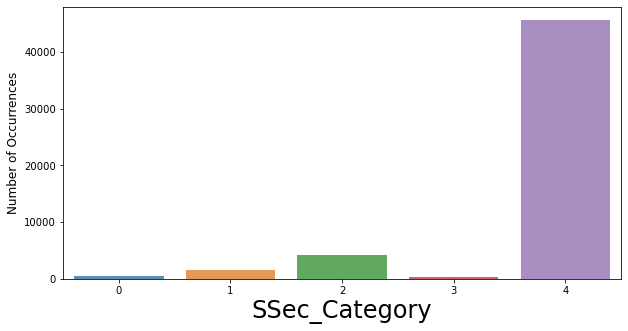

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


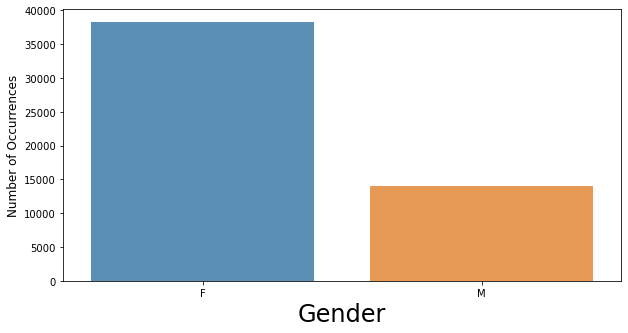

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


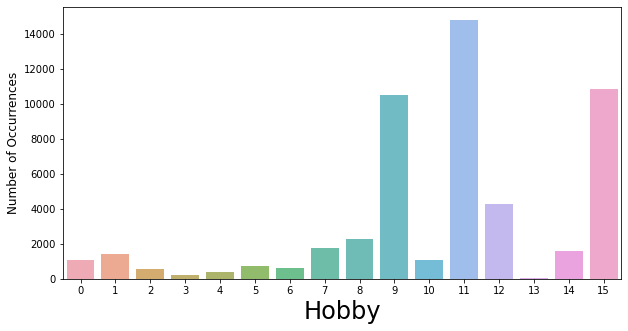

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


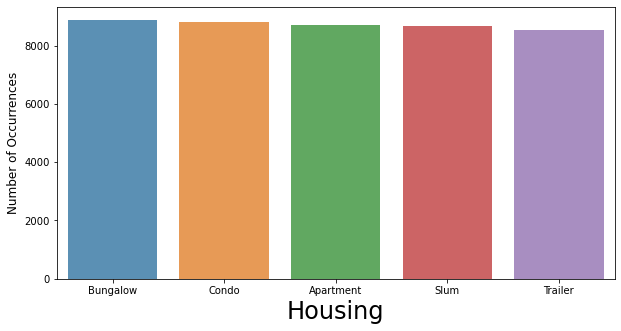

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


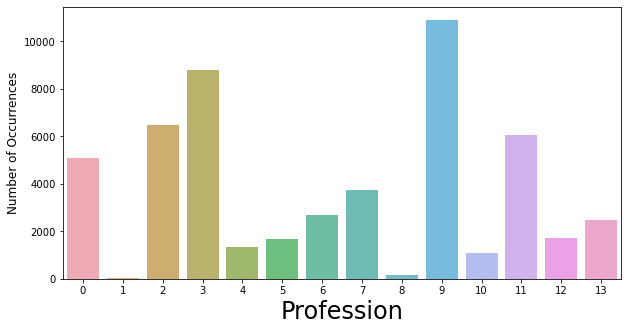

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


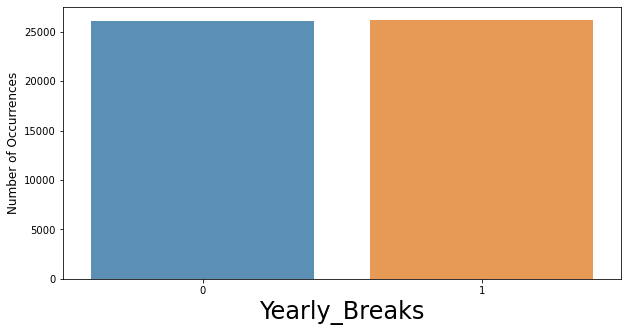

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


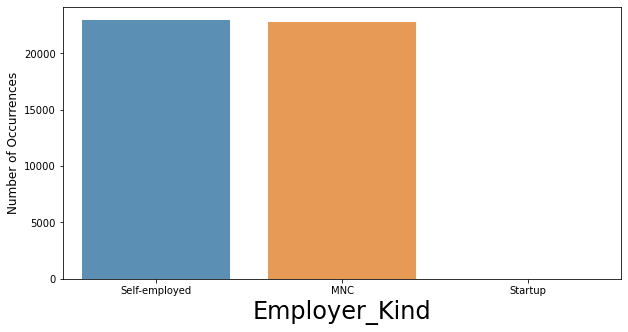

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


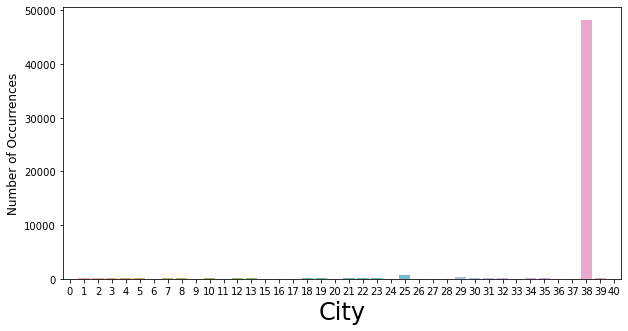

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


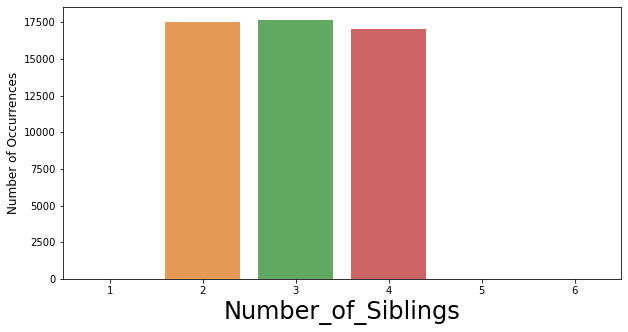

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


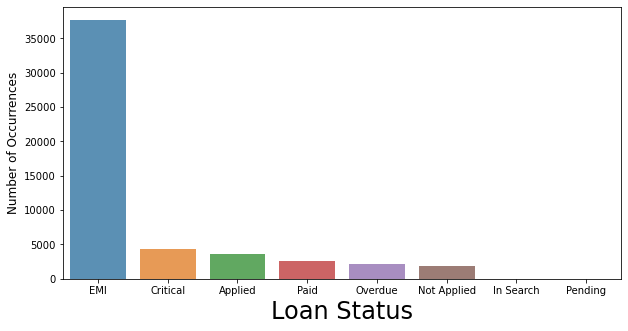

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


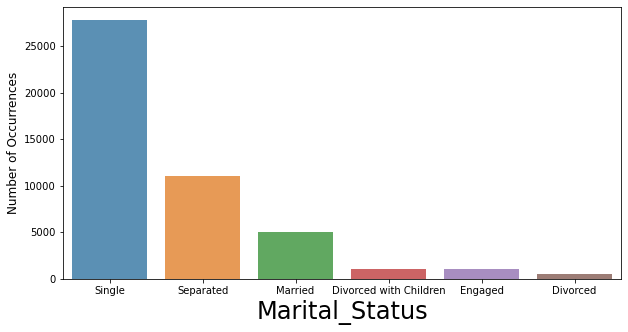

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


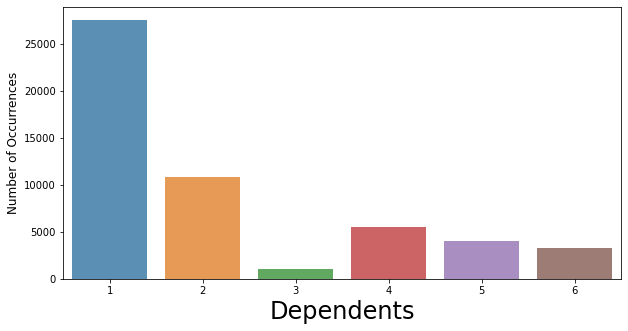

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


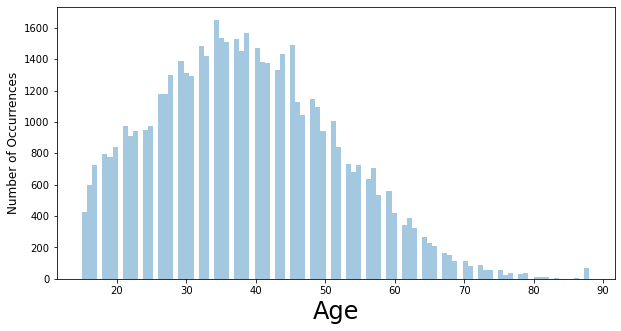

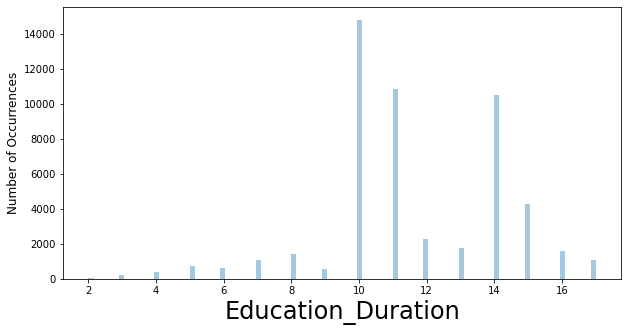

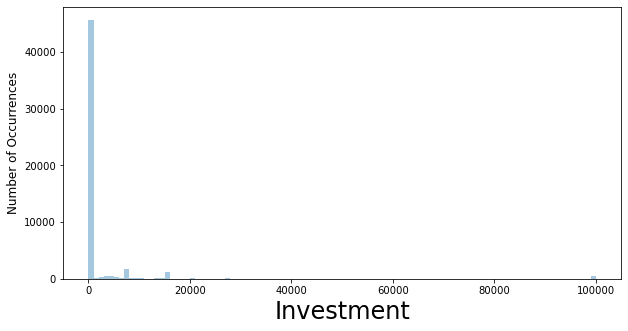

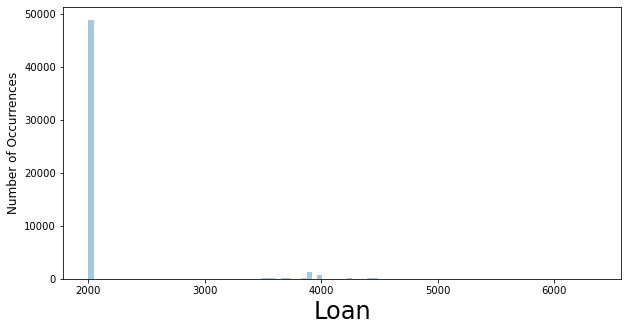

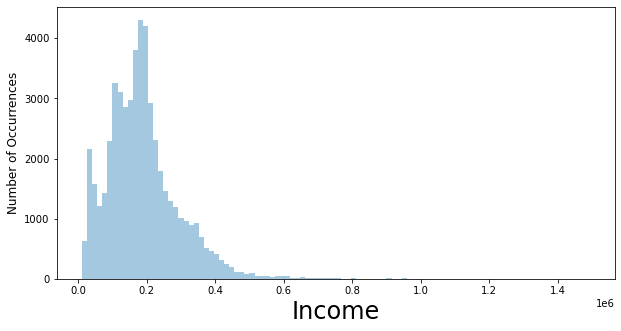

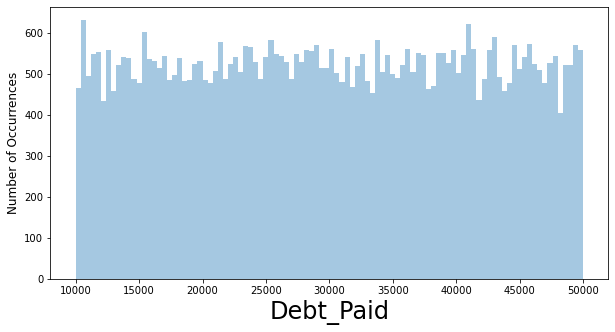

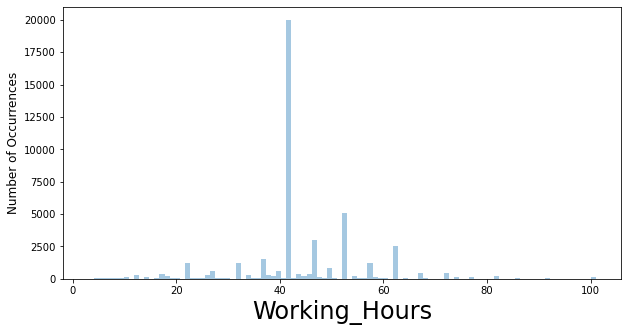

In [4]:
plot_f('SSec_Category')         # v. skewed
plot_f('Gender')                # lil skewed
plot_f('Hobby')                 # lil skewed
plot_f('Housing')
plot_f('Profession')
plot_f('Yearly_Breaks')
plot_f('Employer_Kind')         # remove only 1 existing outlier
plot_f('City')                  # v. skewed
plot_f('Number_of_Siblings')    # v. skewed
plot_f('Loan Status')           # lil skewed
plot_f('Marital_Status')        # lil skewed
plot_f('Dependents')        
plot_cont('Age')
plot_cont('Education_Duration')
plot_cont('Investment')         # v. skewed
plot_cont('Loan')                  # v. skewed
plot_cont('Income')
plot_cont('Debt_Paid')
plot_cont('Working_Hours')

In [5]:
def categorize(df):
        
    df["Number_of_Siblings"][df["Number_of_Siblings"] == 2] = 1
    df["Number_of_Siblings"][df["Number_of_Siblings"] == 5] = 4
    df["Number_of_Siblings"][df["Number_of_Siblings"] == 6] = 4
    
    df["City"][df["City"] != 38] = 2
    df["City"][df["City"] == 38] = 1
    
    df["Employer_Kind"][df["Employer_Kind"] == "Startup"] = "Self-employed"

    df["Housing"][df["Housing"] == "Treehouse"] = "Trailer"
    
    df["Loan Status"][df["Loan Status"] == "Overdue"] = "Not Applied"
    df["Loan Status"][df["Loan Status"] == "In Search"] = "Not Applied"
    df["Loan Status"][df["Loan Status"] == "Pending"] = "Not Applied"
    df["Loan Status"][df["Loan Status"] == "Paid"] = "EMI"
    df["Loan Status"][df["Loan Status"] == "Not Applied"] = "Critical"
    
    df["Marital_Status"][df["Marital_Status"] == "Divorced"] = "Separated"
    df["Marital_Status"][df["Marital_Status"] == "Divorced with Children"] = "Separated"
    df["Marital_Status"][df["Marital_Status"] == "Engaged"] = "Married"
    
    df['Loan'] = pd.cut(df['Loan'], bins=[0,2001,6356], labels=[1,2])
    df['Age'] = pd.cut(df['Age'], bins=[14,29,38,47,88], labels=[1,2,3,4])
    df['Working_Hours'] = pd.cut(df['Working_Hours'], bins=[0,41,43,101], labels=[1,2,3])
    df['Dependents'] = pd.cut(df['Dependents'], bins=[0,1,2,7], labels=[1,2,3])
    df['Investment'] = pd.cut(df['Investment'], bins=[0,50,100020], labels=[1,2])
    df['Education_Duration'] = pd.cut(df['Education_Duration'], bins=[0,10,17], labels=[1,2])
    df['Income'] = pd.cut(df['Income'], bins=[1.176659e+04,1.178404e+05,1.774999e+05,2.355202e+05,1.492729e+06], labels=[1,2,3,4])
    df['Debt_Paid'] = pd.cut(df['Debt_Paid'], bins=[10000.000000,20082.000000,29925.000000,40001.000000,49999.000000], labels=[1,2,3,4])
    
    df['Housing'] = df['Housing'].map( {'Bungalow': 1, 'Condo': 2, 'Apartment': 3, 'Slum': 4, 'Trailer': 5, 'None':6} ).astype(int)
    df['Loan Status'] = df['Loan Status'].map( {'EMI': 1, 'Critical': 2, 'Applied': 3} ).astype(int)
    df['Gender'] = df['Gender'].map( {'M': 1, 'F': 2} ).astype(int)
    df['Marital_Status'] = df['Marital_Status'].map( {'Single': 1, 'Separated': 2, 'Married': 3, 'None':4} ).astype(int)
    df['Employer_Kind'] = df['Employer_Kind'].map( {'Self-employed': 1, 'MNC': 2, 'None':3} ).astype(int)

    return df

    
X['Working_Hours'].fillna((X['Working_Hours'].mean()), inplace=True)
X['Housing'].fillna("None", inplace=True)
X['Marital_Status'].fillna("None", inplace=True)
X['Employer_Kind'].fillna("None", inplace=True)


test_data['Working_Hours'].fillna((test_data['Working_Hours'].mean()), inplace=True)
test_data['Housing'].fillna("None", inplace=True)
test_data['Marital_Status'].fillna("None", inplace=True)
test_data['Employer_Kind'].fillna("None", inplace=True)


X=categorize(X)
test_data=categorize(test_data)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


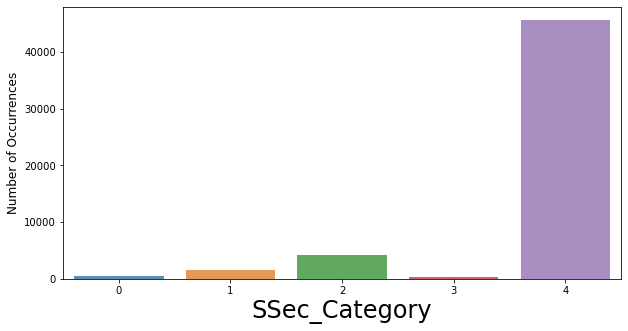

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


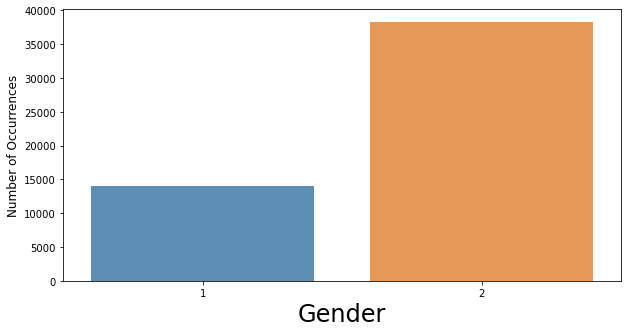

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


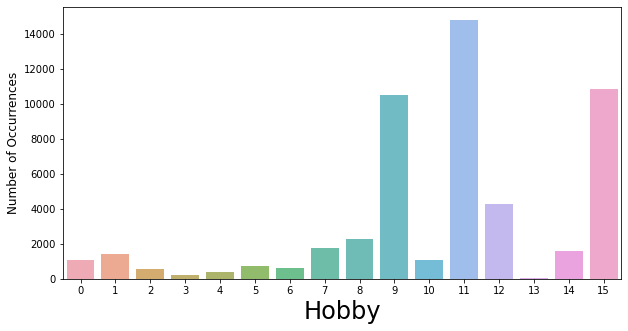

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


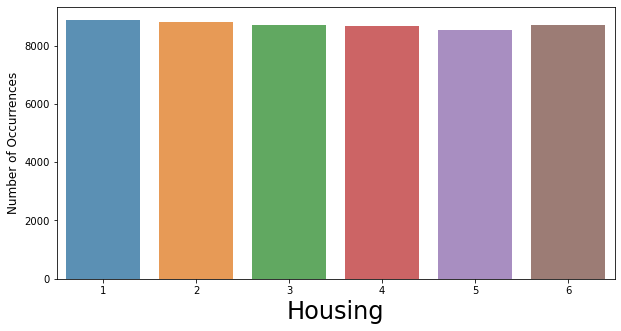

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


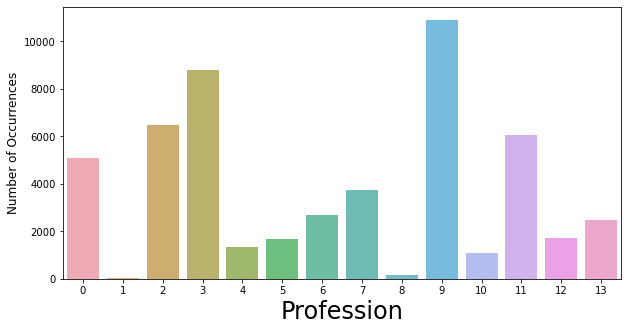

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


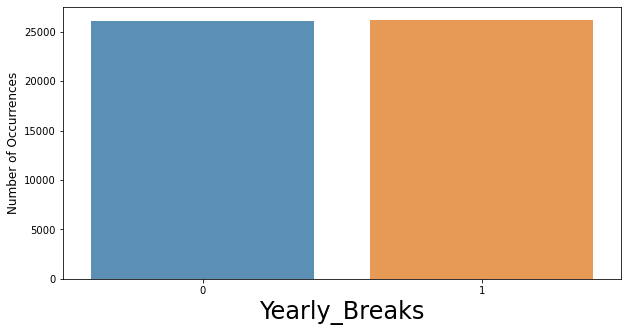

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


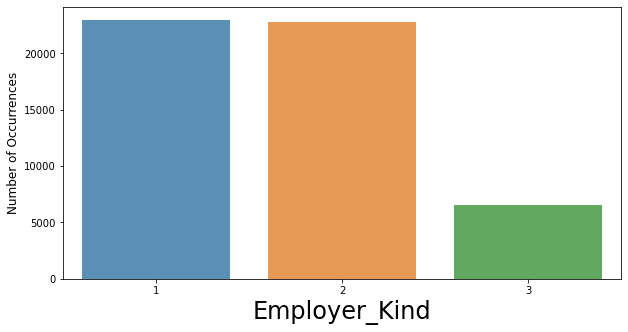

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


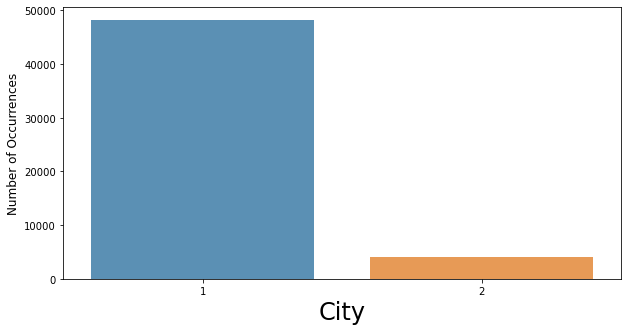

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


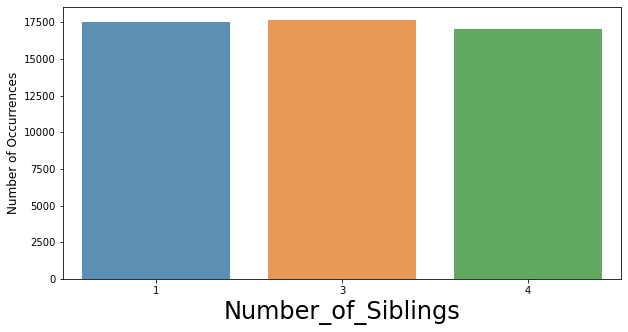

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


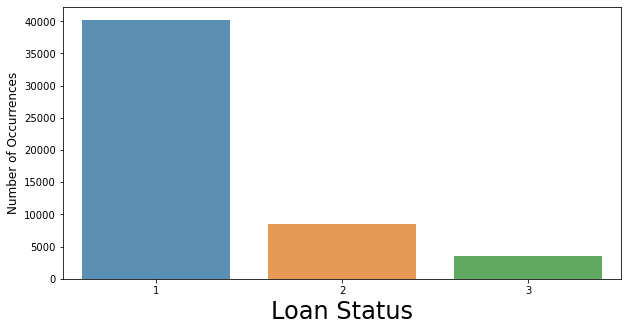

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


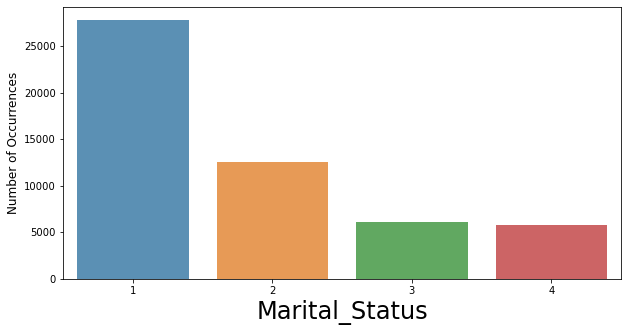

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


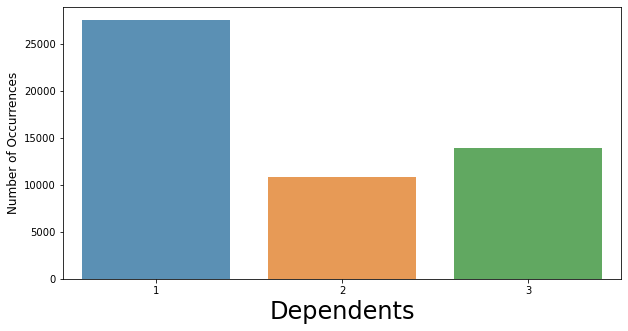

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


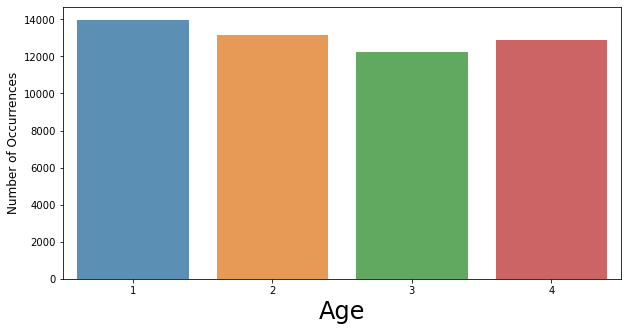

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


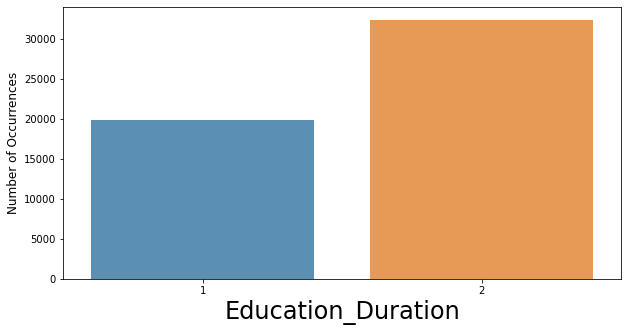

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


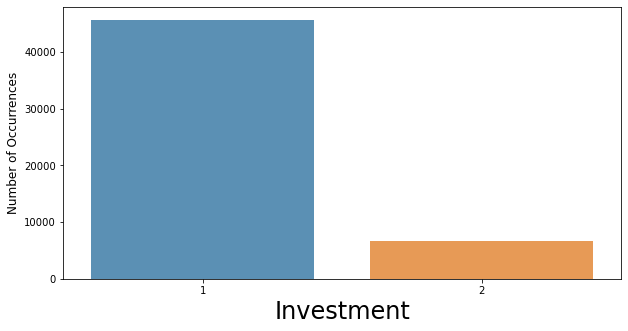

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


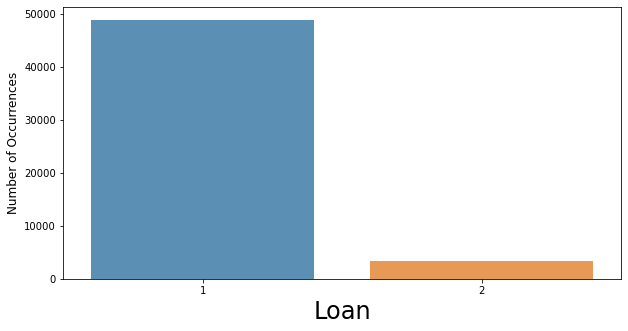

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


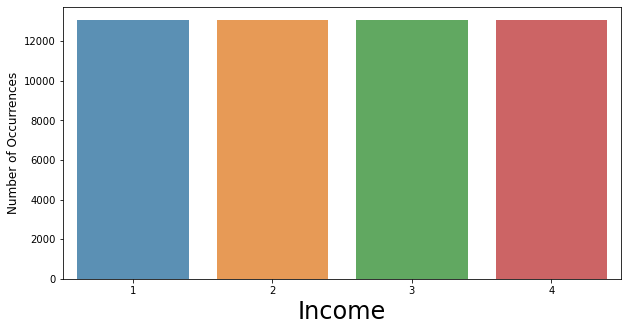

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


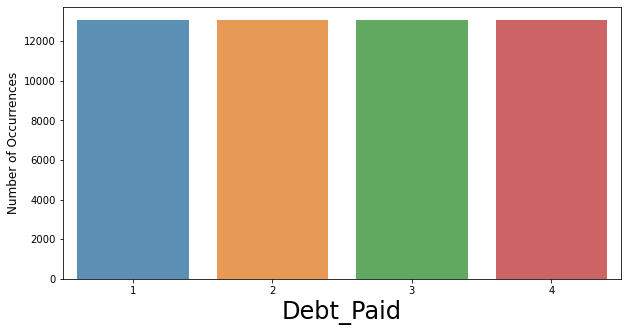

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


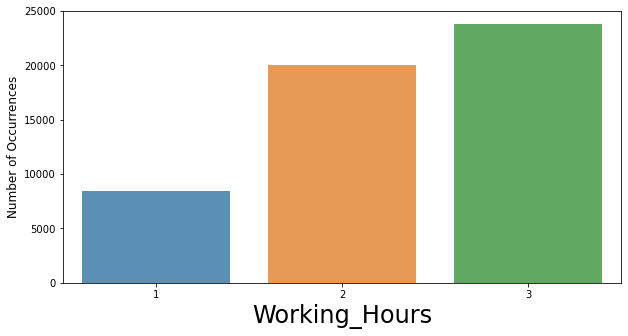

In [6]:
plot_f('SSec_Category')         # v. skewed
plot_f('Gender')                # lil skewed
plot_f('Hobby')                 
plot_f('Housing')
plot_f('Profession')
plot_f('Yearly_Breaks')
plot_f('Employer_Kind')         
plot_f('City')                  # v. skewed
plot_f('Number_of_Siblings')    
plot_f('Loan Status')           # skewed
plot_f('Marital_Status')        # skewed
plot_f('Dependents')        
plot_f('Age')
plot_f('Education_Duration')
plot_f('Investment')            # v. skewed
plot_f('Loan')                  # v. skewed
plot_f('Income')
plot_f('Debt_Paid')
plot_f('Working_Hours')

<AxesSubplot:title={'center':'Pearson Correlation of Features'}>

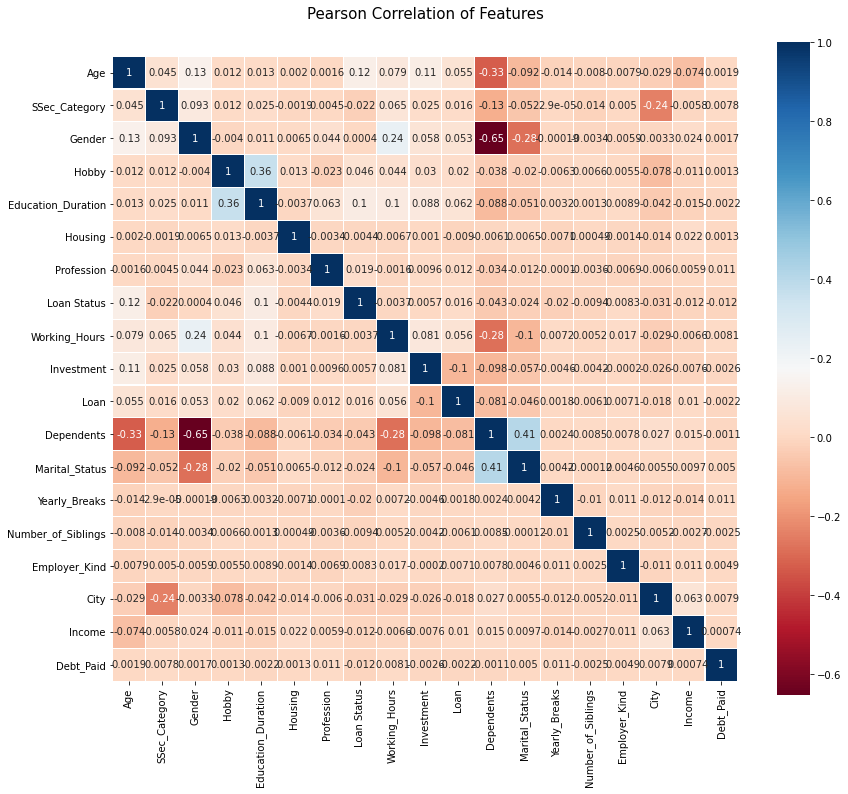

In [7]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(X.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)

In [8]:
# gender and dependents are too dependent so we can deete one, gender is quite skewed so lets go with that
X.drop(['SSec_Category','City','Loan','Investment'],axis=1, inplace=True)
test_data.drop(['SSec_Category','City','Loan','Investment'],axis=1, inplace=True)

Okay so now we have analysed the cols on a basic level.
1. if they are skewed beyond control then i am deleting the col
2. if only some classses are less remove those outliers or combine classes if outliers are tooo many


In [9]:
X

,Age,Gender,Hobby,Education_Duration,Housing,Profession,Loan Status,Working_Hours,Dependents,Marital_Status,Yearly_Breaks,Number_of_Siblings,Employer_Kind,Income,Debt_Paid
0,2,2,9,2,4,0,2,3,2,4,1,3,3,1,1
1,4,2,9,2,2,3,2,1,1,1,0,3,2,1,2
2,2,2,11,1,2,5,1,2,2,3,1,3,2,3,1
3,4,2,1,1,2,5,1,2,1,1,0,3,2,3,3
4,1,1,9,2,4,9,1,2,3,1,1,3,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31671,3,2,9,2,1,11,2,3,1,1,0,4,2,4,2
28037,2,2,7,2,6,3,1,2,1,1,1,1,1,3,3
9771,4,2,15,2,5,11,1,1,1,4,1,1,1,3,4
6007,1,1,9,2,2,12,1,2,3,1,1,1,1,4,4


In [10]:
def one_hot_enc(X):
#     X = pd.concat([X,pd.get_dummies(X["Gender"],prefix='Gender')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Housing"],prefix='Housing')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Marital_Status"],prefix='Marital_Status')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Age"],prefix='Age')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Education_Duration"],prefix='Education_Duration')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Income"],prefix='Income')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Debt_Paid"],prefix='Debt_Paid')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Working_Hours"],prefix='Working_Hours')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Dependents"],prefix='Dependents')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Gender"],prefix='Gender')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Profession"],prefix='Profession')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Hobby"],prefix='Hobby')],axis=1)
#     X = pd.concat([X,pd.get_dummies(X["Loan Status"],prefix='Loan_status')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Yearly_Breaks"],prefix='Yearly_Breaks')],axis=1)
#     X = pd.concat([X,pd.get_dummies(X["Employer_Kind"],prefix='Employer_Kind')],axis=1)
    X = pd.concat([X,pd.get_dummies(X["Number_of_Siblings"],prefix='Number_of_Siblings')],axis=1)
    # 'Loan Status','Yearly_Breaks','Employer_Kind' arent there in best performing
    X.drop(['Dependents','Housing','Marital_Status','Age','Education_Duration','Income','Debt_Paid','Working_Hours','Gender','Profession','Hobby','Loan Status','Yearly_Breaks','Employer_Kind','Number_of_Siblings'],axis=1, inplace=True)
    return X

X_OHE = one_hot_enc(X)
test_data_OHE = one_hot_enc(test_data)

X_OHE

,Housing_1,Housing_2,Housing_3,Housing_4,Housing_5,Housing_6,Marital_Status_1,Marital_Status_2,Marital_Status_3,Marital_Status_4,Age_1,Age_2,Age_3,Age_4,Education_Duration_1,Education_Duration_2,Income_1,Income_2,Income_3,Income_4,Debt_Paid_1,Debt_Paid_2,Debt_Paid_3,Debt_Paid_4,Working_Hours_1,Working_Hours_2,Working_Hours_3,Dependents_1,Dependents_2,Dependents_3,Gender_1,Gender_2,Profession_0,Profession_1,Profession_2,Profession_3,Profession_4,Profession_5,Profession_6,Profession_7,Profession_8,Profession_9,Profession_10,Profession_11,Profession_12,Profession_13,Hobby_0,Hobby_1,Hobby_2,Hobby_3,Hobby_4,Hobby_5,Hobby_6,Hobby_7,Hobby_8,Hobby_9,Hobby_10,Hobby_11,Hobby_12,Hobby_13,Hobby_14,Hobby_15,Yearly_Breaks_0,Yearly_Breaks_1,Number_of_Siblings_1,Number_of_Siblings_3,Number_of_Siblings_4
0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0
3,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31671,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
28037,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0
9771,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0
6007,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0


In [11]:
# from sklearn.preprocessing import MinMaxScaler

# X = np.asarray(X).astype(np.float32)
# y = np.asarray(y).astype(np.float32)
# test_data = np.asarray(test_data).astype(np.float32)

# scaler = MinMaxScaler()
# # transform data
# X = scaler.fit_transform(X)
# test_data =  scaler.fit_transform(test_data)
# print(X)

In [12]:
X_OHE = X_OHE.values
y = y.values
test_data_OHE = test_data_OHE.values

X_train_OHE, X_test_OHE, y_train, y_test = train_test_split(X_OHE, y, test_size=0.3, random_state=42, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)


# NEURAL_NETWORK

In [13]:
bs = 16
input_size = X_OHE.shape[1]
eps = 5
Analysis = ["Model", "Train Acc.", "Validation Acc.", "Distribution"]

model = Sequential()
model.add(Dense(64, input_dim = input_size, activation = 'tanh'))
model.add(Dropout(0.2))
model.add(Dense(32, activation = 'tanh'))
model.add(Dense(1, activation = 'sigmoid'))

opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics = ['AUC']) #AUC to handle class imbalance

model.fit(X_train_OHE, y_train, epochs=eps, batch_size=bs)


pred_train = model.predict(X_train_OHE).round(0).astype(int)
print("Train ROC_AUC = " ,roc_auc_score(y_train, pred_train) )

pred_val = model.predict(X_test_OHE).round(0).astype(int)
print("Validation ROC_AUC = " ,roc_auc_score(y_test, pred_val) )

pred_test = model.predict(test_data_OHE)
ss["Answer"] = (pred_test > 0.5).astype(np.int)
print(ss["Answer"].value_counts())
ss.to_csv('NNtanh_Submission.csv', index=False)
Analysis.append(["NNtanh", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])


Epoch 1/5
2287/2287 [==============================] - 4s 1ms/step - loss: 0.4648 - auc: 0.8586
Epoch 2/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4380 - auc: 0.8742
Epoch 3/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4342 - auc: 0.8764
Epoch 4/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4303 - auc: 0.8786
Epoch 5/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4312 - auc: 0.8785
Train ROC_AUC =  0.8061281525504858
Validation ROC_AUC =  0.7987909003065441
0    9093
1    5444
Name: Answer, dtype: int64


In [14]:
bs = 16
input_size = X_OHE.shape[1]
eps = 5
Analysis = ["Model", "Train Acc.", "Validation Acc.", "Distribution"]

model = Sequential()
model.add(Dense(64, input_dim = input_size, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

opt = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics = ['AUC']) #AUC to handle class imbalance

model.fit(X_train_OHE, y_train, epochs=eps, batch_size=bs)


pred_train = model.predict(X_train_OHE).round(0).astype(int)
print("Train ROC_AUC = " ,roc_auc_score(y_train, pred_train) )

pred_val = model.predict(X_test_OHE).round(0).astype(int)
print("Validation ROC_AUC = " ,roc_auc_score(y_test, pred_val) )

pred_test = model.predict(test_data_OHE)
ss["Answer"] = (pred_test > 0.5).astype(np.int)
print(ss["Answer"].value_counts())
ss.to_csv('NN_Submission.csv', index=False)
Analysis.append(["NN", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])


Epoch 1/5
2287/2287 [==============================] - 4s 1ms/step - loss: 0.4652 - auc: 0.8583
Epoch 2/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4359 - auc: 0.8759
Epoch 3/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4211 - auc: 0.8854
Epoch 4/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4210 - auc: 0.8840
Epoch 5/5
2287/2287 [==============================] - 3s 1ms/step - loss: 0.4136 - auc: 0.8872
Train ROC_AUC =  0.8158211959630678
Validation ROC_AUC =  0.803339081034253
0    8855
1    5682
Name: Answer, dtype: int64


# Random_Forest_CLassifier

In [15]:
RFC = RandomForestClassifier()
RFC.fit(X_train, y_train)

pred_train = RFC.predict(X_train)
print( "Train ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = RFC.predict(X_test)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = RFC.predict(test_data)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('RFC_Submission.csv', index=False)  
Analysis.append(["Random FC", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])


Train ROC_AUC =  0.9989354018094309
Validation ROC_AUC =  0.9099776755964281
0    10764
1     3773
Name: Answer, dtype: int64


# XGBoost

In [16]:
XGBC = xgb.XGBClassifier(
        #learning_rate = 0.02,
        n_estimators= 2000,
        max_depth= 4,
        min_child_weight= 2,
        #gamma=1,
        gamma=0.9,                        
        subsample=0.8,
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread= -1,
        scale_pos_weight=1
        ).fit(X_train_OHE, y_train)

pred_train = XGBC.predict(X_train_OHE)
print( "Training ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = XGBC.predict(X_test_OHE)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = XGBC.predict(test_data_OHE)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('XGBC_submission.csv', index=False)

Analysis.append(["XGB", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[08:57:13] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Training ROC_AUC =  0.9243022199032627
Validation ROC_AUC =  0.8609243802479009
0    10100
1     4437
Name: Answer, dtype: int64


# LIGHTGBM

In [17]:

d_train=lgb.Dataset(X_train, label=y_train)

#Specifying the parameter
params={}
params['learning_rate']=0.03
params['boosting_type']='gbdt' #GradientBoostingDecisionTree
params['objective']='binary' #Binary target feature
params['metric']='binary_logloss' #metric for binary classification
params['max_depth']=10

#train the model 
LGBM=lgb.train(params,d_train,5000) #train the model on 100 epocs

pred_train = LGBM.predict(X_train).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = LGBM.predict(X_test).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = LGBM.predict(test_data).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('LGBM_submission.csv', index=False)

Analysis.append(["LGBM", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Find whitespaces in feature_names, replace with underlines
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 18261, number of negative: 18325
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81
[LightGBM] [Info] Number of data points in the train set: 36586, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499125 -> initscore=-0.003499
[LightGBM] [Info] Start training from score -0.003499



Training ROC_AUC =  0.9576302414444847
Validation ROC_AUC =  0.8886450628082101
0    10327
1     4

# Linear Regression

In [18]:


LR = LogisticRegression()
LR.fit(X_train_OHE, y_train)

pred_train = LR.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = LR.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = LR.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('LR_submission.csv', index=False)

Analysis.append(["Logistic Reg.", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.7941756072495278
Validation ROC_AUC =  0.7954271416433427
0    9348
1    5189
Name: Answer, dtype: int64


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


# Naive Bayes

In [19]:

NB = GaussianNB()
NB.fit(X_train_OHE, y_train)

pred_train = NB.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = NB.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = NB.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('NB_submission.csv', index=False)

Analysis.append(["Naive bayes", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.7648988245549432
Validation ROC_AUC =  0.7653313674530189
0    7687
1    6850
Name: Answer, dtype: int64


# SGD Classifier

In [20]:

SGD = SGDClassifier(max_iter=1000,loss="modified_huber", shuffle=True, random_state=23)
SGD.fit(X_train_OHE, y_train)

pred_train = SGD.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = SGD.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = SGD.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('NB_submission.csv', index=False)

Analysis.append(["SGD Classifier", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.7892995061079259
Validation ROC_AUC =  0.7898377107490336
0    9182
1    5355
Name: Answer, dtype: int64


# K-Neighbors Classifier

In [21]:

KNN = KNeighborsClassifier(n_neighbors=15)
KNN.fit(X_train_OHE, y_train)

pred_train = KNN.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = KNN.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = KNN.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('KNN_submission.csv', index=False)

Analysis.append(["KNeighborsClassifier", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.8205242791109928
Validation ROC_AUC =  0.7961820480141276
0    8770
1    5767
Name: Answer, dtype: int64


# Decision Tree Classifier

In [22]:

DTREE = DecisionTreeClassifier(max_depth=10, random_state=101, max_features=None, min_samples_leaf=15 )
DTREE.fit(X_train_OHE, y_train)

pred_train = DTREE.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = DTREE.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = DTREE.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('DTREE_submission.csv', index=False)

Analysis.append(["DTREE", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])




Training ROC_AUC =  0.81620092410241
Validation ROC_AUC =  0.8025237821538052
0    9150
1    5387
Name: Answer, dtype: int64


# SVC Rbf

In [23]:

SVM_rbf = SVC(kernel="rbf", C=0.025, random_state=101)
SVM_rbf.fit(X_train_OHE, y_train)

pred_train = SVM_rbf.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = SVM_rbf.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = SVM_rbf.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('SVM_rbf_submission.csv', index=False)

Analysis.append(["SVM_rbf", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.7829374494268457
Validation ROC_AUC =  0.7820444738771158
0    8723
1    5814
Name: Answer, dtype: int64


# SVC

In [24]:

SVM = SVC(kernel="linear", C=0.025, random_state=101)
SVM.fit(X_train_OHE, y_train)

pred_train = SVM.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = SVM.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = SVM.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('SVM_submission.csv', index=False)

Analysis.append(["SVM", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.7933013041981163
Validation ROC_AUC =  0.7934555344528855
0    9044
1    5493
Name: Answer, dtype: int64


# Perceptron

In [25]:
from sklearn.linear_model import Perceptron
PPN = Perceptron(eta0=1, random_state=1)
PPN.fit(X_train_OHE, y_train)

pred_train = PPN.predict(X_train_OHE).round(0).astype(int)
print( "\n\n\nTraining ROC_AUC = ",roc_auc_score(y_train, pred_train) )

pred_val = PPN.predict(X_test_OHE).round(0).astype(int)
print( "Validation ROC_AUC = ",roc_auc_score(y_test, pred_val) )

pred_test = PPN.predict(test_data_OHE).round(0).astype(int)
ss["Answer"] = pred_test
print(ss["Answer"].value_counts())
ss.to_csv('PPN_submission.csv', index=False)

Analysis.append(["PPN", roc_auc_score(y_train, pred_train), roc_auc_score(y_test, pred_val), ss["Answer"].value_counts()])





Training ROC_AUC =  0.6444506632007785
Validation ROC_AUC =  0.6384498284019726
1    10874
0     3663
Name: Answer, dtype: int64


In [26]:
pprint.pprint(Analysis, indent=0)

['Model',
'Train Acc.',
'Validation Acc.',
'Distribution',
['NN',
0.8158211959630678,
0.803339081034253,
0    8855
1    5682
Name: Answer, dtype: int64],
['Random FC',
0.9989354018094309,
0.9099776755964281,
0    10764
1     3773
Name: Answer, dtype: int64],
['XGB',
0.9243022199032627,
0.8609243802479009,
0    10100
1     4437
Name: Answer, dtype: int64],
['LGBM',
0.9576302414444847,
0.8886450628082101,
0    10327
1     4210
Name: Answer, dtype: int64],
['Logistic Reg.',
0.7941756072495278,
0.7954271416433427,
0    9348
1    5189
Name: Answer, dtype: int64],
['Naive bayes',
0.7648988245549432,
0.7653313674530189,
0    7687
1    6850
Name: Answer, dtype: int64],
['SGD Classifier',
0.7892995061079259,
0.7898377107490336,
0    9182
1    5355
Name: Answer, dtype: int64],
['KNeighborsClassifier',
0.8205242791109928,
0.7961820480141276,
0    8770
1    5767
Name: Answer, dtype: int64],
['DTREE',
0.81620092410241,
0.8025237821538052,
0    9150
1    5387
Name: Answer, dtype: int64],
['SVM_rbf',

# Ensemble

In [27]:
pred_test_0 = model.predict(test_data_OHE)
pred_test_0 = (pred_test > 0.5).astype(np.int)
pred_test_1 = SVM.predict(test_data_OHE).round(0).astype(int)
pred_test_2 = LR.predict(test_data_OHE).round(0).astype(int)
pred_test_3 = LGBM.predict(test_data).round(0).astype(int)
pred_test_4 = NB.predict(test_data_OHE).round(0).astype(int)
pred_test_5 = XGBC.predict(test_data_OHE)

en_pred = (pred_test_0+ pred_test_1 +pred_test_2 +pred_test_3)/4
en_pred = (en_pred >= 0.5).astype(np.int)
ss["Answer"] = en_pred
print(ss["Answer"].value_counts())
ss.to_csv('Ensemble1_submission.csv', index=False)

en_pred = (pred_test_0+ pred_test_4 +pred_test_5 +pred_test_3)/4
en_pred = (en_pred >= 0.5).astype(np.int)
ss["Answer"] = en_pred
print(ss["Answer"].value_counts())
ss.to_csv('Ensemble2_submission.csv', index=False)

en_pred = (pred_test_0+ pred_test_1 +pred_test_2 +pred_test_3+pred_test_4+pred_test_5)/4
en_pred = (en_pred >= 0.5).astype(np.int)
ss["Answer"] = en_pred
print(ss["Answer"].value_counts())
ss.to_csv('Ensemble3_submission.csv', index=False)

0    8562
1    5975
Name: Answer, dtype: int64
0    7363
1    7174
Name: Answer, dtype: int64
1    7356
0    7181
Name: Answer, dtype: int64
